# Evaluating the output of the SCIP solver of CVXPY

In [6]:
from av_mat_generation.CI_based.window import Window
from datetime import datetime
import pandas as pd
import numpy as np
import cvxpy as cp
MAIN_FOLDER = 'availability_matrices/av-mat-9'

In [2]:
start_time=datetime(2022, 1, 1, 0, 0)
win = Window(start_time=start_time,random_start=False, out_folder=MAIN_FOLDER, countries=["Belgium", "Ireland", "Germany", "France", "Great Britain", "Finland", "Sweden"], n_rounds=50)
res = win.get_GHG_matrix()
min_carbon_budget = res[[i for i in range(47,50)]].sum().sum()
total_cb = res.sum().sum()
print(1-min_carbon_budget/total_cb)

0.9426946878443885


In [3]:
win = Window(start_time=start_time,random_start=False, out_folder=MAIN_FOLDER, \
            countries=["Belgium", "Ireland", "Germany", "France", "Great Britain", "Finland", "Sweden"], n_rounds=50)

In [4]:
carbon_budget_considered = res.sum().cumsum().to_numpy().take([44,39,34,29,24,19,14,9,8,4,3])
print(carbon_budget_considered)

[8.838905999999998 7.980065999999999 7.111268999999998 6.1960109999999995
 5.279057999999999 4.235079 3.032562 1.983414 1.773765 0.9428550000000001
 0.7447260000000001]


Carbon budget : 8.838905999999998
Time elapsed: 0.05553007125854492


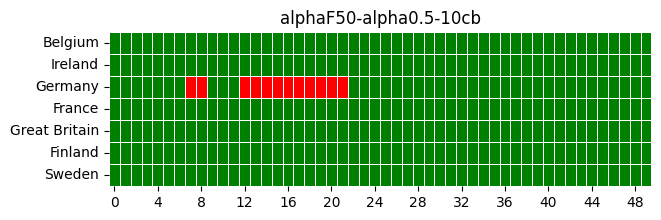

target:  8.838905999999998
result:  8.803437
Carbon budget : 7.980065999999999
Time elapsed: 0.06434202194213867


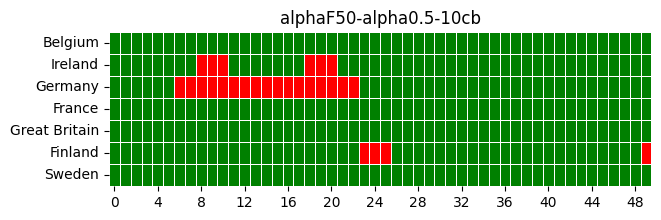

target:  7.980065999999999
result:  7.949304
Carbon budget : 7.111268999999998
Time elapsed: 0.10002422332763672


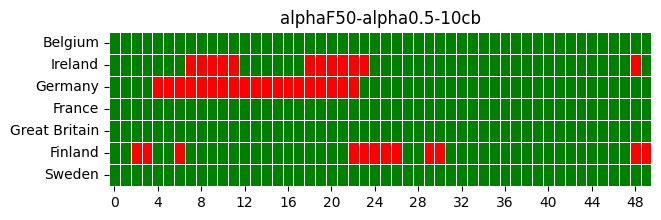

target:  7.111268999999998
result:  7.096376999999998
Carbon budget : 6.1960109999999995
Time elapsed: 0.6170060634613037


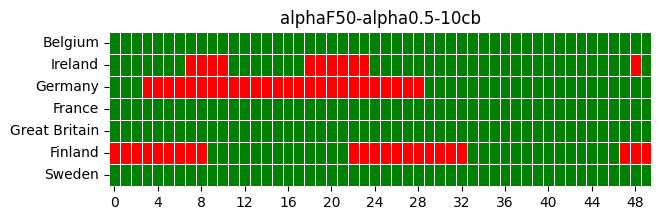

target:  6.1960109999999995
result:  6.195584999999996
Carbon budget : 5.279057999999999
Time elapsed: 0.5497720241546631


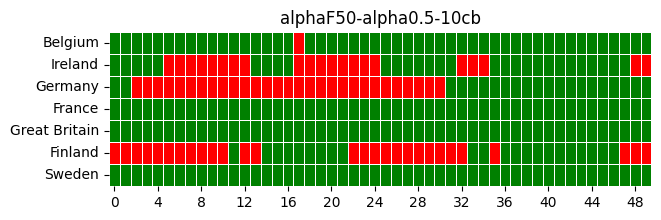

target:  5.279057999999999
result:  5.278710000000001
Carbon budget : 4.235079
Time elapsed: 1.4007689952850342


/Users/danielrichardsr/prjkts/FedStale/venv/lib/python3.12/site-packages/cvxpy/problems/problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


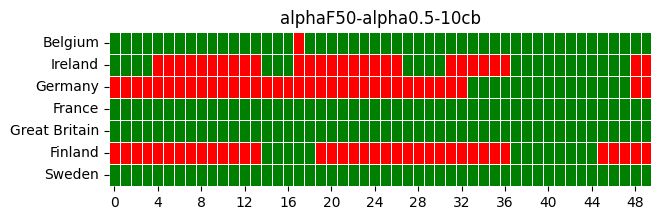

target:  4.235079
result:  4.231236000000002
Carbon budget : 3.032562
Time elapsed: 0.11732101440429688


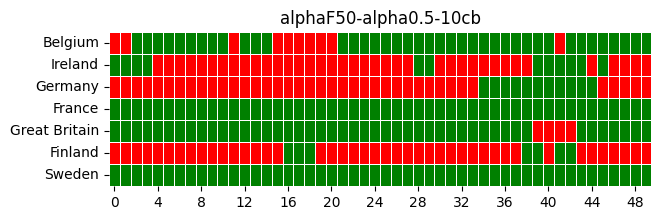

target:  3.032562
result:  3.0321480000000007
Carbon budget : 1.983414
Time elapsed: 2.0644729137420654


/Users/danielrichardsr/prjkts/FedStale/venv/lib/python3.12/site-packages/cvxpy/problems/problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


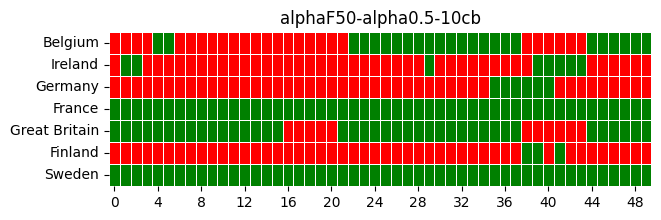

target:  1.983414
result:  1.9820549999999997
Carbon budget : 1.773765
Time elapsed: 0.7780971527099609


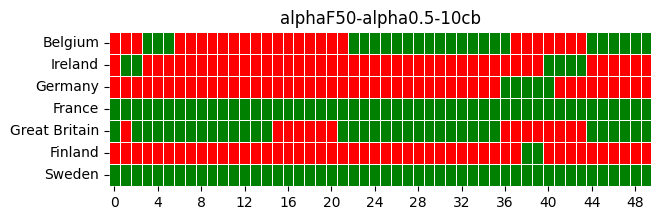

target:  1.773765
result:  1.7535779999999999
Carbon budget : 0.9428550000000001
Time elapsed: 1.8352439403533936


/Users/danielrichardsr/prjkts/FedStale/venv/lib/python3.12/site-packages/cvxpy/problems/problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


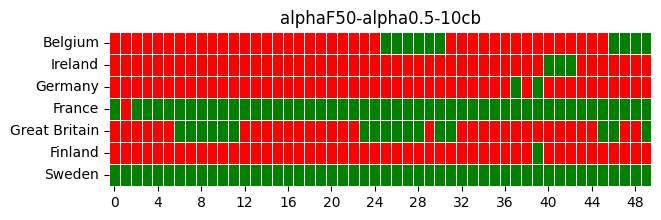

target:  0.9428550000000001
result:  0.9406950000000002
Carbon budget : 0.7447260000000001
Time elapsed: 0.41788482666015625


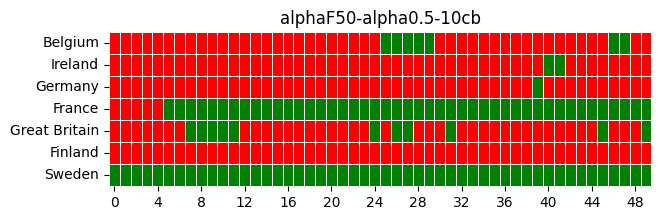

target:  0.7447260000000001
result:  0.6585300000000001


In [8]:
alpha_val = 0.5
for carbon_budget in carbon_budget_considered:
    print("Carbon budget :", carbon_budget)
    win = Window(start_time=start_time,random_start=False, out_folder=MAIN_FOLDER, \
        countries=["Belgium", "Ireland", "Germany", "France", "Great Britain", "Finland", "Sweden"], n_rounds=50)
    # for alpha_val in [0.001, 0.01, 0.1, 0.5, 0.75, 0.9, 1.0]:
    av_mat = win.get_av_mat(method='cvxpy_scip', fine_tuning=False, carbon_budget=carbon_budget, key_word=f"alphaF50-alpha{alpha_val}-{CO2saving+1}cb", alpha_f=alpha_val)

Carbon budget : 0.9428550000000001


/home/danny/hdd/prjkts/FedStale/venv/lib/python3.12/site-packages/cvxpy/problems/problem.py:1481: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


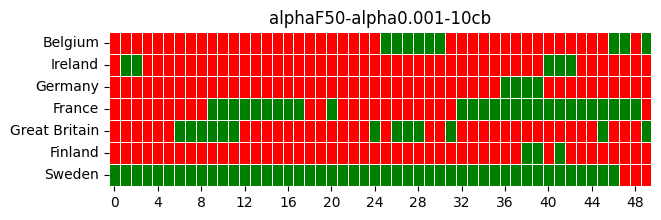

target:  0.9428550000000001
result:  0.9424560000000001


/home/danny/hdd/prjkts/FedStale/venv/lib/python3.12/site-packages/cvxpy/problems/problem.py:1481: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


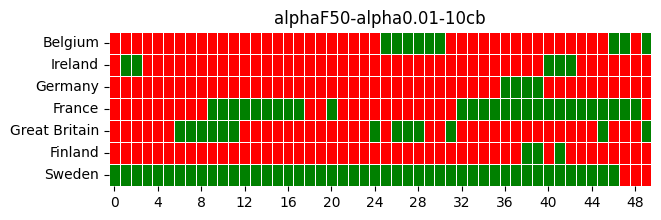

target:  0.9428550000000001
result:  0.9424560000000001


/home/danny/hdd/prjkts/FedStale/venv/lib/python3.12/site-packages/cvxpy/problems/problem.py:1481: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


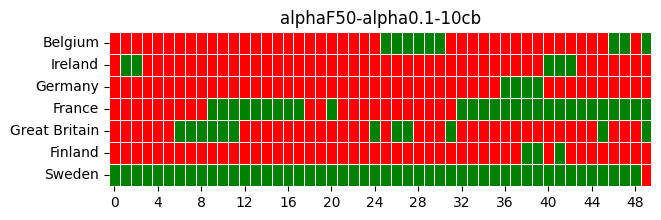

target:  0.9428550000000001
result:  0.9421020000000001


/home/danny/hdd/prjkts/FedStale/venv/lib/python3.12/site-packages/cvxpy/problems/problem.py:1481: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


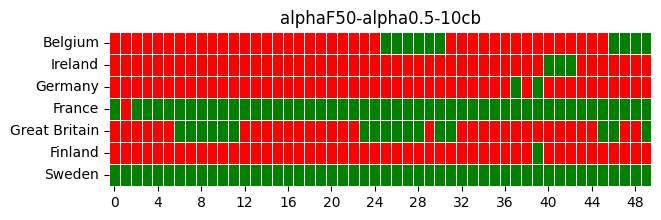

target:  0.9428550000000001
result:  0.9406950000000002


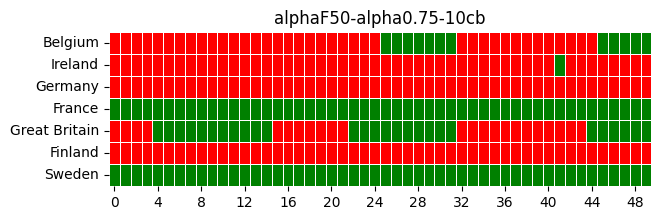

target:  0.9428550000000001
result:  0.9421920000000001


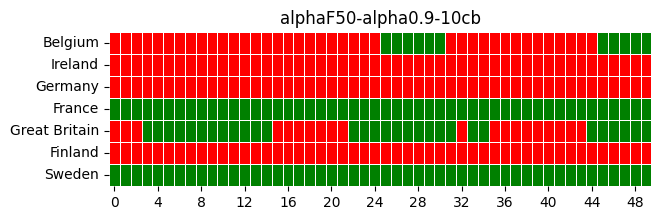

target:  0.9428550000000001
result:  0.9400109999999999


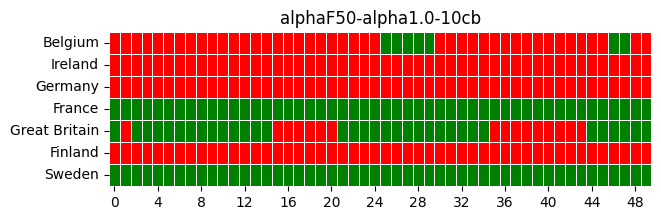

target:  0.9428550000000001
result:  0.9341729999999998


In [7]:
CO2saving = 9
carbon_budget = carbon_budget_considered[CO2saving]
print("Carbon budget :", carbon_budget)
win = Window(start_time=start_time,random_start=False, out_folder=MAIN_FOLDER, \
    countries=["Belgium", "Ireland", "Germany", "France", "Great Britain", "Finland", "Sweden"], n_rounds=50)
for alpha_val in [0.001, 0.01, 0.1, 0.5, 0.75, 0.9, 1.0]:
    av_mat = win.get_av_mat(method='cvxpy_scip', fine_tuning=False, carbon_budget=carbon_budget, key_word=f"alphaF50-alpha{alpha_val}-{CO2saving+1}cb", alpha_f=alpha_val)